In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('data/used_cars.csv')

In [ ]:
# data cleaning
df = df[['model_year', 'milage', 'fuel_type',"accident", "price"]].dropna()
df_new = df[~df['fuel_type'].isin(["not supported", "–"])].copy(deep=True)
df_new['price'] = df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df_new['milage'] = (
    df_new['milage']
    .str.replace(r'[^\d]', '', regex=True)  # keep only digits
    .astype(float)
)
# def simplify_fuel(x):
#     x = x.lower()
#     if 'gas' in x:
#         return 'gasoline'
#     elif 'hybrid' in x:
#         return 'hybrid'
#     elif 'electric' in x:
#         return 'electric'
#     else:
#         return 'other'

# df_new['fuel_type'] = df_new['fuel_type'].apply(simplify_fuel)
df_new['fuel_type'] = df_new['fuel_type'].astype('category')
df_new['accident'] = df_new['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
current_year = 2026
df_new['age'] = current_year - df_new['model_year'].astype(int)
print(df_new.head())

   model_year   milage      fuel_type  accident    price  age
0        2013  51000.0  E85 Flex Fuel         1  10300.0   13
1        2021  34742.0       Gasoline         1  38005.0    5
2        2022  22372.0       Gasoline         0  54598.0    4
3        2015  88900.0         Hybrid         0  15500.0   11
4        2021   9835.0       Gasoline         0  34999.0    5
['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Diesel', 'Plug-In Hybrid']
Categories (5, object): ['Diesel', 'E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Plug-In Hybrid']


In [4]:
print(df_new['fuel_type'].unique())


['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Diesel', 'Plug-In Hybrid']
Categories (5, object): ['Diesel', 'E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Plug-In Hybrid']


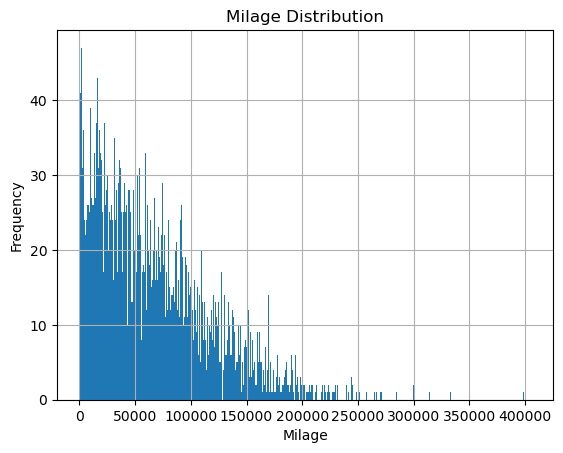

np.False_

In [ ]:
# visualizations
df_new["milage"].hist(bins=500)
plt.title('Milage Distribution')
plt.xlabel('Milage')
plt.ylabel('Frequency')
plt.show()

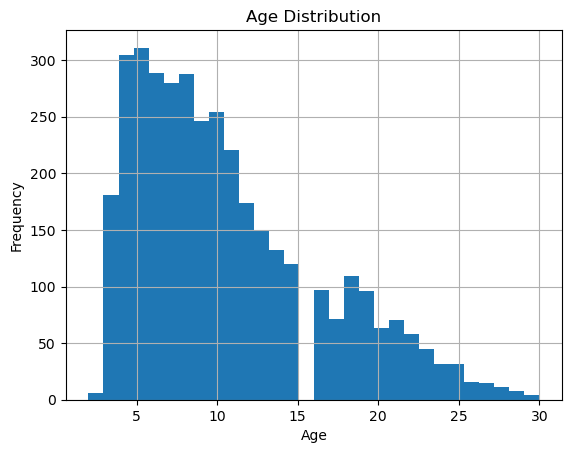

In [6]:
df_new["age"].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

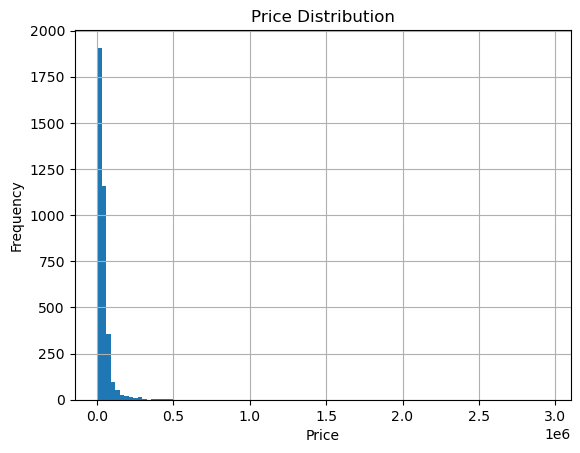

2954083.0


In [8]:
df_new["price"].hist(bins=100)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()
print(df_new['price'].max())


Text(0.5, 1.0, 'Accident vs Price')

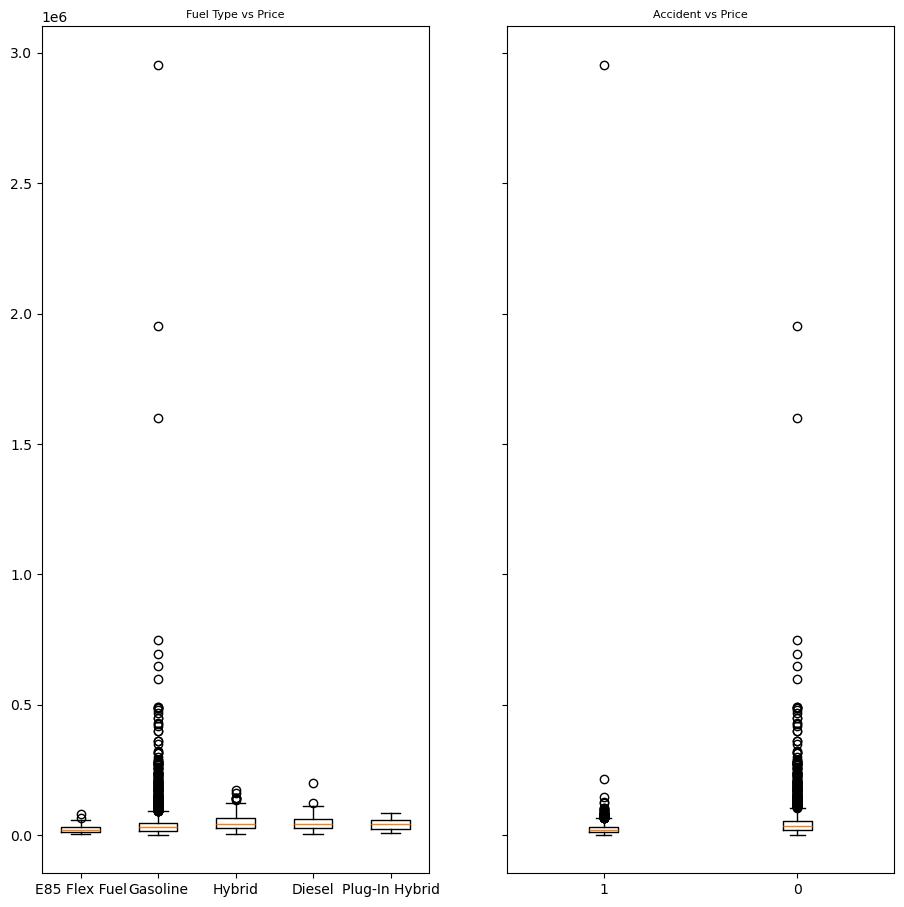

In [21]:
# Visualization part 1
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11, 11), sharey=True)
# Boxplot of fuel type vs price:
fuel_types = df_new["fuel_type"].unique()
price_groups = [df_new[df_new["fuel_type"] == ft]["price"] for ft in fuel_types]

axs[0].boxplot(price_groups, tick_labels=fuel_types)
axs[0].set_title('Fuel Type vs Price', fontsize=8)
# Boxplot of accident vs price:
accident_types = df_new["accident"].unique()
price_groups_acc = [df_new[df_new["accident"] == ac]["price"] for ac in accident_types]

axs[1].boxplot(price_groups_acc, tick_labels=accident_types)
axs[1].set_title('Accident vs Price', fontsize=8)

Text(0.5, 1.0, 'Mileage vs. Car Price')

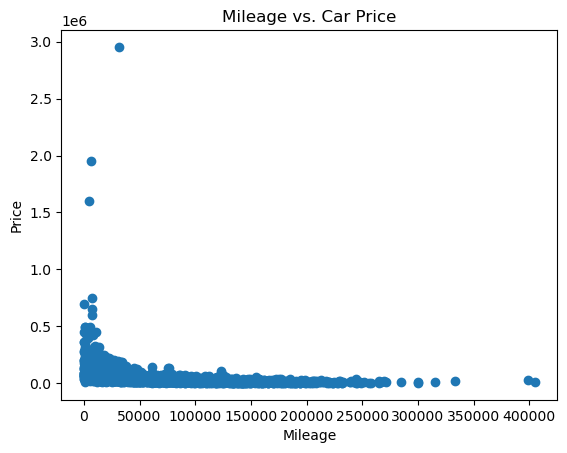

In [15]:
# Visualization part 2:
# Scatter plot of Mileage vs price:
plt.scatter(df_new["milage"], df_new["price"])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs. Car Price")

Text(0.5, 1.0, 'Car Age (Binned) vs Price')

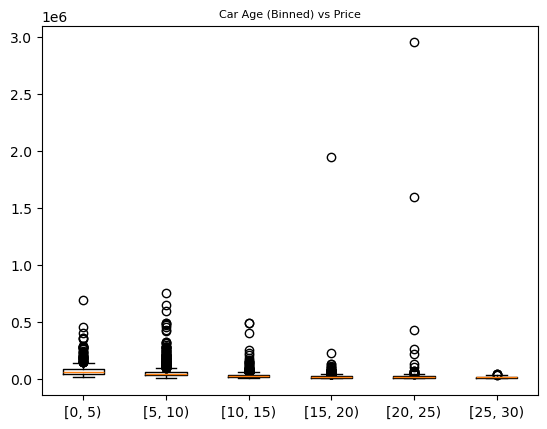

In [22]:
# Scatter plot of Mileage vs price:
# Boxplot of Car Age vs Price
df_new["age_bin"] = pd.cut(df_new["age"], bins=[0, 5, 10, 15, 20,25,30], right=False)

age_types = df_new["age_bin"].cat.categories
price_groups = [df_new[df_new["age_bin"] == b]["price"] for b in age_types]

plt.boxplot(price_groups, tick_labels=age_types)
plt.title('Car Age (Binned) vs Price', fontsize=8)